# Distribuce počtu lezi na obratel

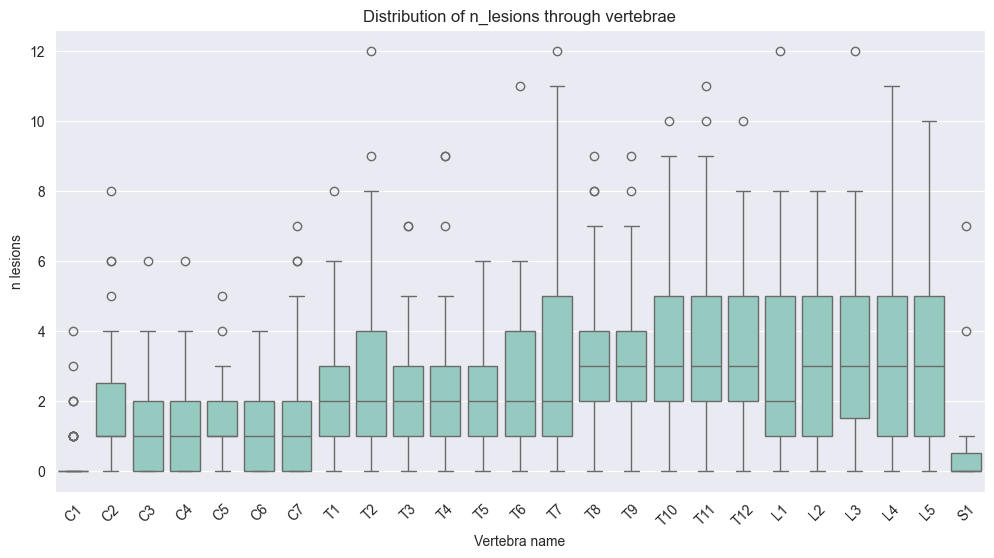

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

main_folder = r"E:\DATA_Myelomy"
all_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)
    csv_path = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")

    if os.path.isfile(csv_path):
        df = pd.read_csv(csv_path)
        df = df[['vertebra_name', 'n_lesions']]
        all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.boxplot(x='vertebra_name', y='n_lesions', data=full_df)
plt.title('Distribution of n_lesions through vertebrae')
plt.xlabel('Vertebra name')
plt.ylabel('n lesions')
plt.xticks(rotation=45)
plt.show()

# Relativní % obejmu lezi na obratel

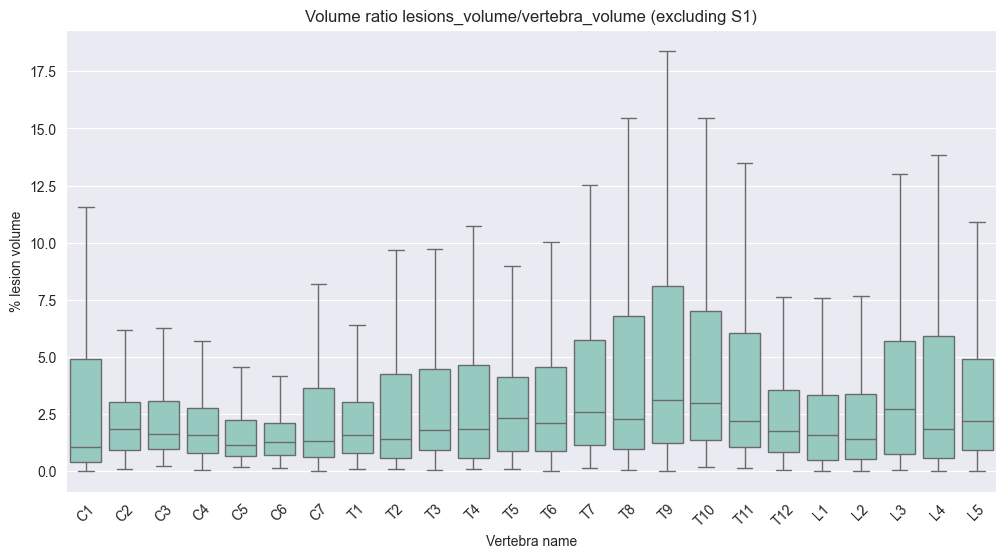

In [35]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

main_folder = r"E:\DATA_Myelomy"

vertebra_data = []
lesion_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    vertebra_csv = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")
    lesion_csv = os.path.join(folder_path, "BMD_radiomics_lesions_features.csv")

    if os.path.isfile(vertebra_csv):
        df_v = pd.read_csv(vertebra_csv)
        df_v = df_v[['vertebra_name', 'original_shape_VoxelVolume']]
        vertebra_data.append(df_v)

    if os.path.isfile(lesion_csv):
        df_l = pd.read_csv(lesion_csv)
        df_l = df_l[['vertebra_name', 'original_shape_VoxelVolume']]
        lesion_data.append(df_l)

# combine all vertebra and lesion data
df_vertebra = pd.concat(vertebra_data, ignore_index=True)
df_lesion = pd.concat(lesion_data, ignore_index=True)

df_lesion["lesions_volume"] = df_lesion["original_shape_VoxelVolume"]
df_vertebra["vertebra_volume"] = df_vertebra["original_shape_VoxelVolume"]

# merge with vertebra volume, fill missing lesion sums with 0
df = pd.merge(df_vertebra, df_lesion, on='vertebra_name', how='left')

# calculate lesion percentage
df['lesion_percent'] = df['lesions_volume'] / df['vertebra_volume'] * 100

# remove S1 vertebra
df = df[df['vertebra_name'] != 'S1']

# visualization
plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.boxplot(x='vertebra_name', y='lesion_percent', data=df, showfliers=False)
plt.title('Volume ratio lesions_volume/vertebra_volume (excluding S1)')
plt.xlabel('Vertebra name')
plt.ylabel('% lesion volume')
plt.xticks(rotation=45)
plt.show()

# % podiel objemu lezi -> štádium

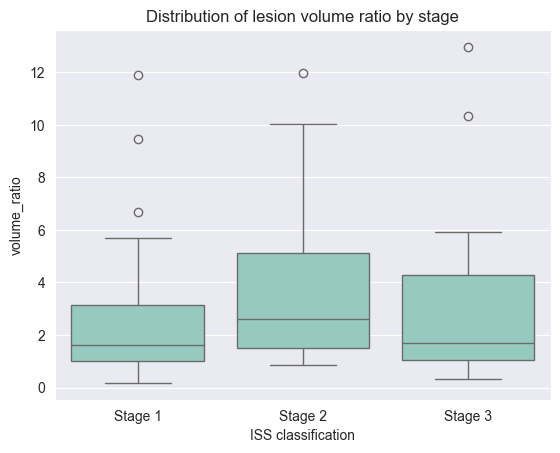

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'ISS classification']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
sns.boxplot(data=df_final, x="ISS classification", y="volume_ratio")
plt.title('Distribution of lesion volume ratio by stage')
plt.show()

# % podiel objemu lezi -> M-protein type

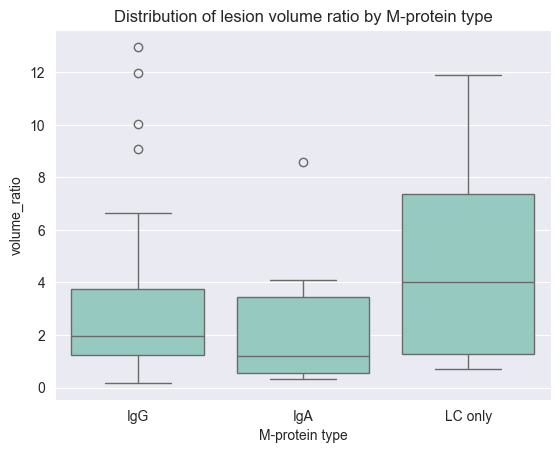

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'M-protein type']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
sns.set_style("darkgrid")
sns.boxplot(data=df_final, x="M-protein type", y="volume_ratio")
plt.title('Distribution of lesion volume ratio by M-protein type')
plt.show()

# % podiel objemu lezi -> štádium (C/T/L)

vertebra_name                  T10
lesions_volume        20997.718414
patient                   Myel_050
vertebra_volume        35849.98661
region                    Thoracic
Patient ID                Myel_050
ISS classification         Stage 2
volume_ratio             58.571063
Name: 803, dtype: object


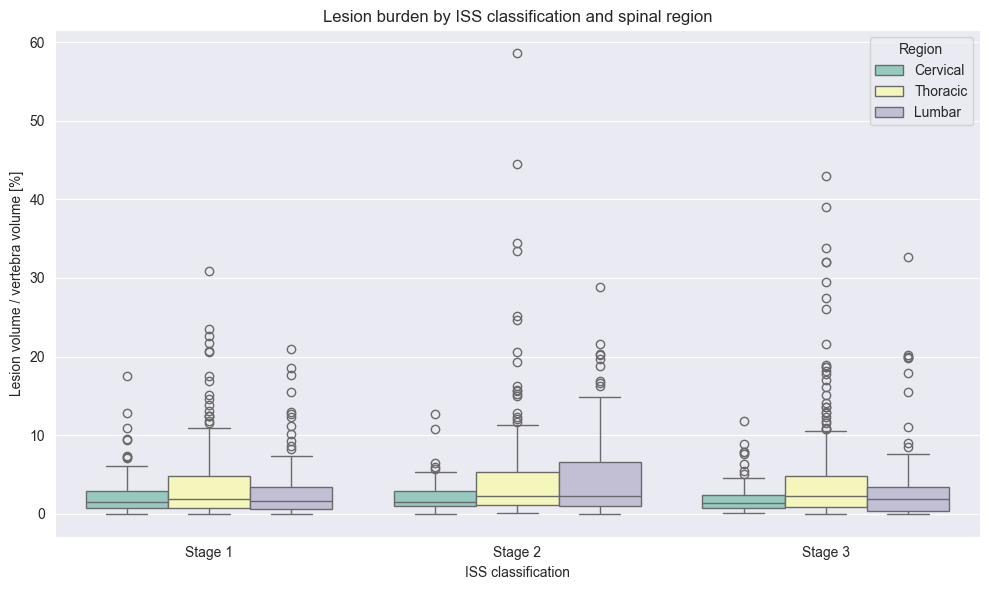

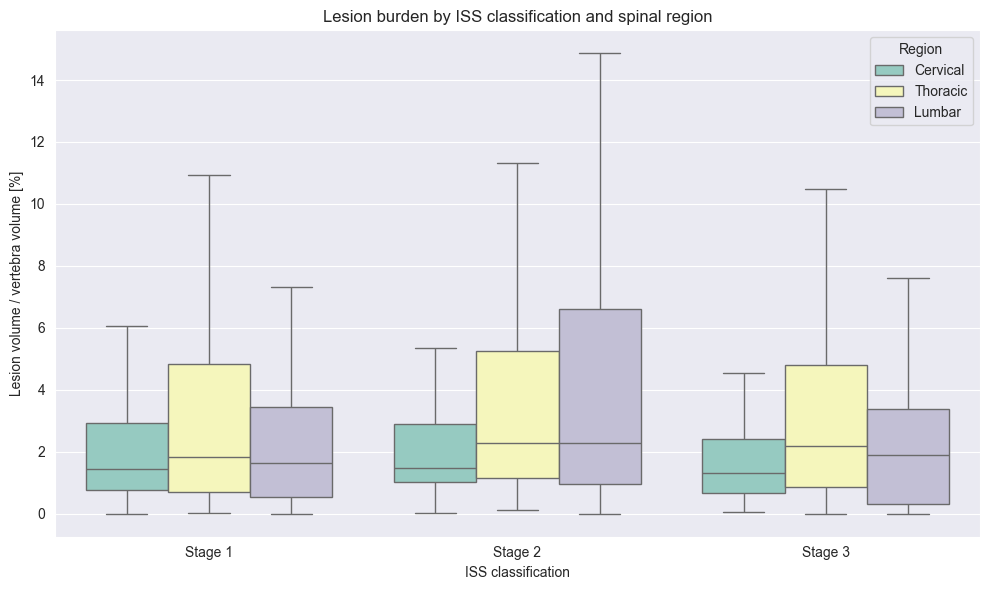

In [31]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# --- 1. Load all lesion CSVs ---
main_folder = r"E:\DATA_Myelomy"

lesion_data = []
vertebra_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    lesion_csv = os.path.join(folder_path, "monoe_40kev_radiomics_lesions_features.csv")
    vertebra_csv = os.path.join(folder_path, "monoe_40kev_radiomics_vertebrae_features.csv")

    # --- lesions ---
    if os.path.isfile(lesion_csv):
        df_l = (pd.read_csv(lesion_csv).filter(items=["vertebra_name", "original_shape_VoxelVolume"]))
        df_l["patient"] = folder_name
        lesion_data.append(df_l)

    # --- vertebrae ---
    if os.path.isfile(vertebra_csv):
        df_v = (pd.read_csv(vertebra_csv).filter(items=["vertebra_name", "original_shape_VoxelVolume"]))
        df_v["patient"] = folder_name
        vertebra_data.append(df_v)

# combine all lesion and vertebra data
df_lesions = (pd.concat(lesion_data, ignore_index=True).rename(columns={"original_shape_VoxelVolume": "lesions_volume"}))
df_vertebra = (pd.concat(vertebra_data, ignore_index=True).rename(columns={"original_shape_VoxelVolume": "vertebra_volume"}))

# --- Merge lesions + vertebrae (ONLY vertebrae with lesions) ---
df = pd.merge(df_lesions, df_vertebra, on=["patient", "vertebra_name"])
df = df[df["vertebra_name"] != "S1"]

# --- 2. Define vertebra regions (C/T/L) ---
cervical = [f'C{i}' for i in range(1,8)]
thoracic = [f'T{i}' for i in range(1,13)]
lumbar = [f'L{i}' for i in range(1,6)]

def map_region(vertebra):
    if vertebra in cervical:
        return 'Cervical'
    elif vertebra in thoracic:
        return 'Thoracic'
    else:
        return 'Lumbar'

df['region'] = df['vertebra_name'].apply(map_region)

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(df, clinical_df[['Patient ID', 'ISS classification']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebra_volume'] * 100
print(df_final.loc[df_final["volume_ratio"].idxmax()])

sns.set_style(style="darkgrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="ISS classification", y="volume_ratio", hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"])
plt.xlabel("ISS classification")
plt.ylabel("Lesion volume / vertebra volume [%]")
plt.title("Lesion burden by ISS classification and spinal region")
plt.legend(title="Region")
plt.tight_layout()
plt.show()
print()
print()
sns.set_style(style="darkgrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="ISS classification", y="volume_ratio", hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"], showfliers=False)
plt.xlabel("ISS classification")
plt.ylabel("Lesion volume / vertebra volume [%]")
plt.title("Lesion burden by ISS classification and spinal region")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

# % podiel objemu lezi -> M-protein type (C/T/L)

vertebra_name               T10
lesions_volume     20997.718414
patient                Myel_050
vertebra_volume     35849.98661
region                 Thoracic
Patient ID             Myel_050
M-protein type              IgG
volume_ratio          58.571063
Name: 803, dtype: object


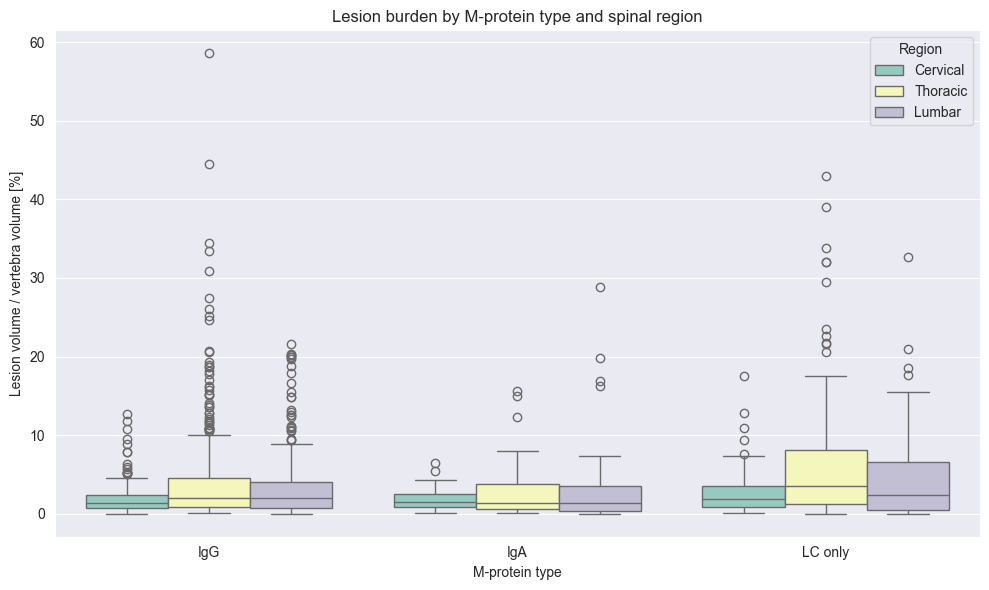

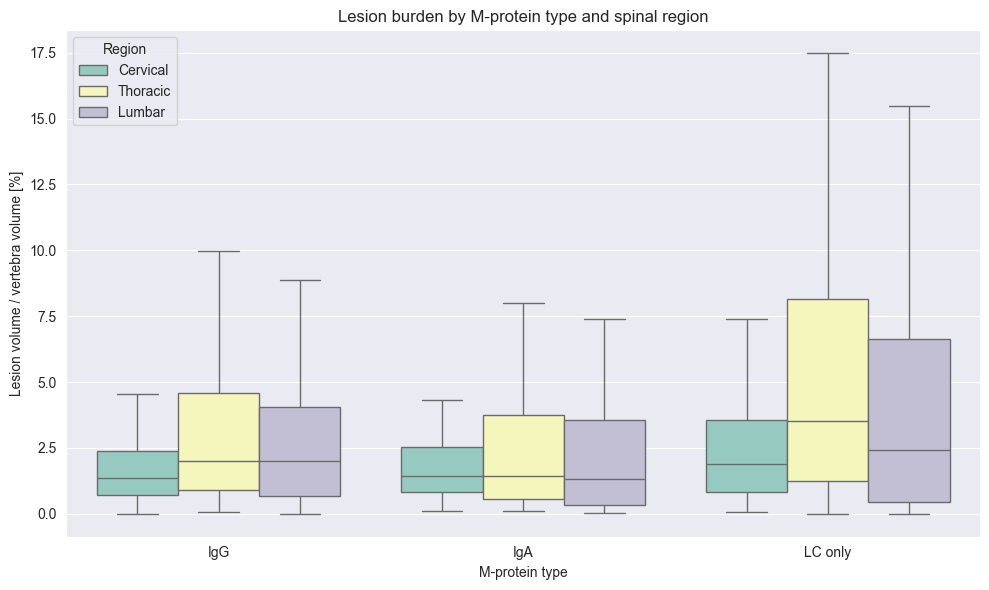

In [33]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# --- 1. Load all lesion CSVs ---
main_folder = r"E:\DATA_Myelomy"

lesion_data = []
vertebra_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    lesion_csv = os.path.join(folder_path, "monoe_40kev_radiomics_lesions_features.csv")
    vertebra_csv = os.path.join(folder_path, "monoe_40kev_radiomics_vertebrae_features.csv")

    # --- lesions ---
    if os.path.isfile(lesion_csv):
        df_l = (pd.read_csv(lesion_csv).filter(items=["vertebra_name", "original_shape_VoxelVolume"]))
        df_l["patient"] = folder_name
        lesion_data.append(df_l)

    # --- vertebrae ---
    if os.path.isfile(vertebra_csv):
        df_v = (pd.read_csv(vertebra_csv).filter(items=["vertebra_name", "original_shape_VoxelVolume"]))
        df_v["patient"] = folder_name
        vertebra_data.append(df_v)

# combine all lesion and vertebra data
df_lesions = (pd.concat(lesion_data, ignore_index=True).rename(columns={"original_shape_VoxelVolume": "lesions_volume"}))
df_vertebra = (pd.concat(vertebra_data, ignore_index=True).rename(columns={"original_shape_VoxelVolume": "vertebra_volume"}))

# --- Merge lesions + vertebrae (ONLY vertebrae with lesions) ---
df = pd.merge(df_lesions, df_vertebra, on=["patient", "vertebra_name"])
df = df[df["vertebra_name"] != "S1"]

# --- 2. Define vertebra regions (C/T/L) ---
cervical = [f'C{i}' for i in range(1,8)]
thoracic = [f'T{i}' for i in range(1,13)]
lumbar = [f'L{i}' for i in range(1,6)]

def map_region(vertebra):
    if vertebra in cervical:
        return 'Cervical'
    elif vertebra in thoracic:
        return 'Thoracic'
    else:
        return 'Lumbar'

df['region'] = df['vertebra_name'].apply(map_region)

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(df, clinical_df[['Patient ID', 'M-protein type']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebra_volume'] * 100
print(df_final.loc[df_final["volume_ratio"].idxmax()])

sns.set_style(style="darkgrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="M-protein type", y="volume_ratio", hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"])
plt.xlabel("M-protein type")
plt.ylabel("Lesion volume / vertebra volume [%]")
plt.title("Lesion burden by M-protein type and spinal region")
plt.legend(title="Region")
plt.tight_layout()
plt.show()
print()
print()
sns.set_style(style="darkgrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="M-protein type", y="volume_ratio", hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"], showfliers=False)
plt.xlabel("M-protein type")
plt.ylabel("Lesion volume / vertebra volume [%]")
plt.title("Lesion burden by M-protein type and spinal region")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

# % podiel objemu lezi -> b2 microglobulin

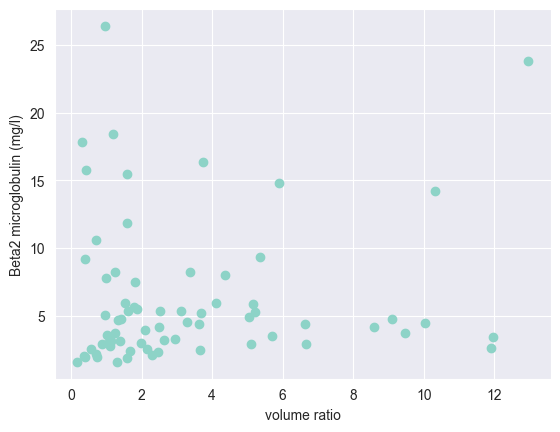

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'Beta2 microglobulin (mg/l)']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
plt.scatter(df_final['volume_ratio'], df_final['Beta2 microglobulin (mg/l)'])
plt.xlabel('volume ratio')
plt.ylabel('Beta2 microglobulin (mg/l)')
plt.show()

# % podiel objemu lezi -> serum M protein, plasmocyte count, creatinine, calcium

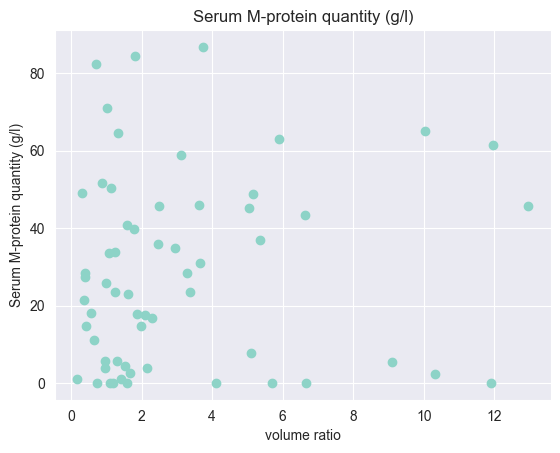

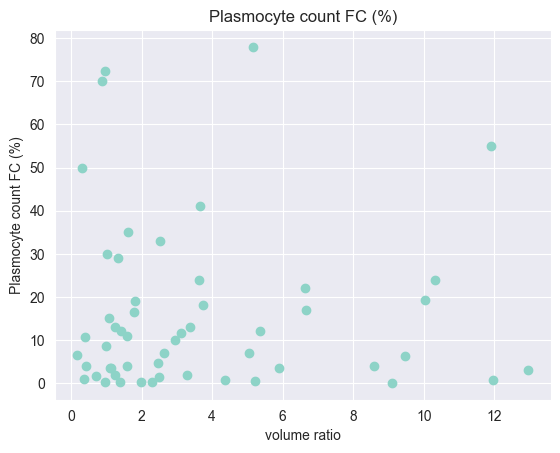

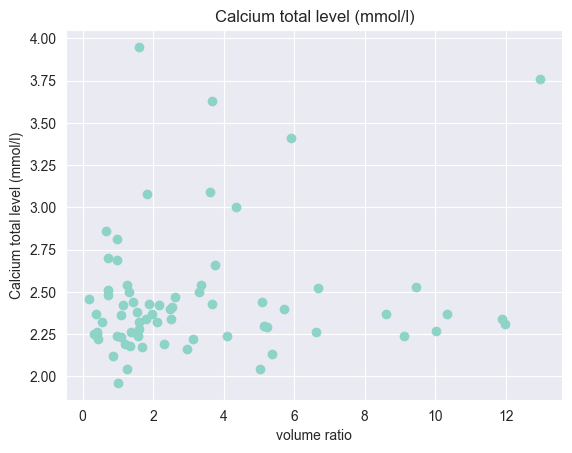

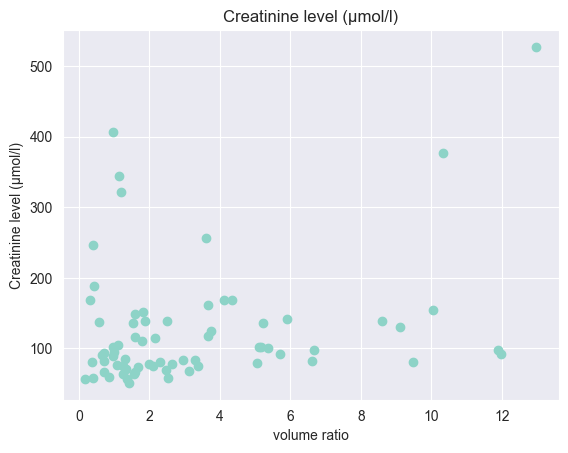

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
features = ["Patient ID", "Serum M-protein quantity (g/l)", "Plasmocyte count FC (%)", "Calcium total level (mmol/l)", "Creatinine level (µmol/l)"]
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[features], left_on='patient', right_on='Patient ID')

for f in features:
    if f == "Patient ID":
        continue
    df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
    plt.scatter(df_final['volume_ratio'], df_final[f])
    plt.xlabel('volume ratio')
    plt.ylabel(f)
    plt.title(f)
    plt.show()

# Difference in features between vertebra -> VMI40

In [56]:
import os
import pandas as pd
from scipy.stats import kruskal

main_folder = r"E:\DATA_Myelomy"
result_rows = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    l_path = os.path.join(folder_path, "monoe_40kev_radiomics_lesions_features.csv")
    v_path = os.path.join(folder_path, "monoe_40kev_radiomics_vertebrae_features.csv")

    if os.path.isfile(l_path) and os.path.isfile(v_path):
        df_l = pd.read_csv(l_path)
        df_v = pd.read_csv(v_path)

        df_l = df_l.set_index('vertebra_name')
        df_v = df_v.set_index('vertebra_name')

        common_cols = df_l.columns.intersection(df_v.columns)

        df_ratio = df_l[common_cols] / df_v[common_cols]

        df_ratio = df_ratio.reset_index()
        result_rows.append(df_ratio)

if not result_rows:
    print("Neboli nájdené žiadne dáta na spracovanie.")
else:
    df = pd.concat(result_rows, ignore_index=True)
    df = df[df['vertebra_name'] != 'S1'].dropna()

    results = []
    feature_cols = df.select_dtypes(include=['number']).columns

    for feature in feature_cols:
        groups = [group[feature].values for _, group in df.groupby('vertebra_name') if len(group) > 0]

        if len(groups) > 1:
            try:
                H, p = kruskal(*groups)
                results.append({'feature': feature, 'H_stat': H, 'p_value': p})
            except (ValueError, TypeError):
                continue

    results_df = pd.DataFrame(results).sort_values('H_stat', ascending=False)
results_df.head()

C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Analysis of multiple myelomas from dual CT\.venv\Lib\site-packages\scipy\stats\_stats_py.py:8492: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties


,feature,H_stat,p_value
139,gradient_glcm_Imc1,642.394151,5.832378e-121
140,gradient_glcm_Imc2,588.264822,1.317717e-109
48,original_glcm_InverseVariance,563.435427,2.067801e-104
42,original_glcm_Id,532.770314,5.249543e-98
46,original_glcm_Imc1,529.924815,2.059151e-97


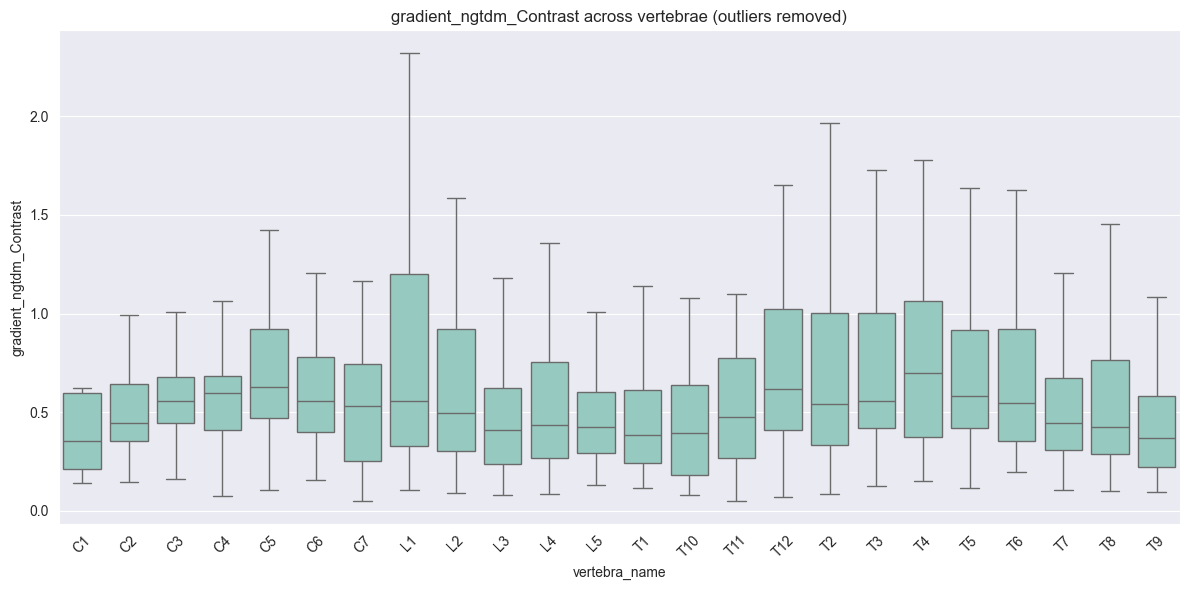

In [61]:
feature_name = 'gradient_ngtdm_Contrast'

plt.figure(figsize=(12,6))
sns.boxplot(x='vertebra_name', y=feature_name, data=df, showfliers=False, order=sorted(df['vertebra_name'].unique()))
plt.title(f'{feature_name} across vertebrae (outliers removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

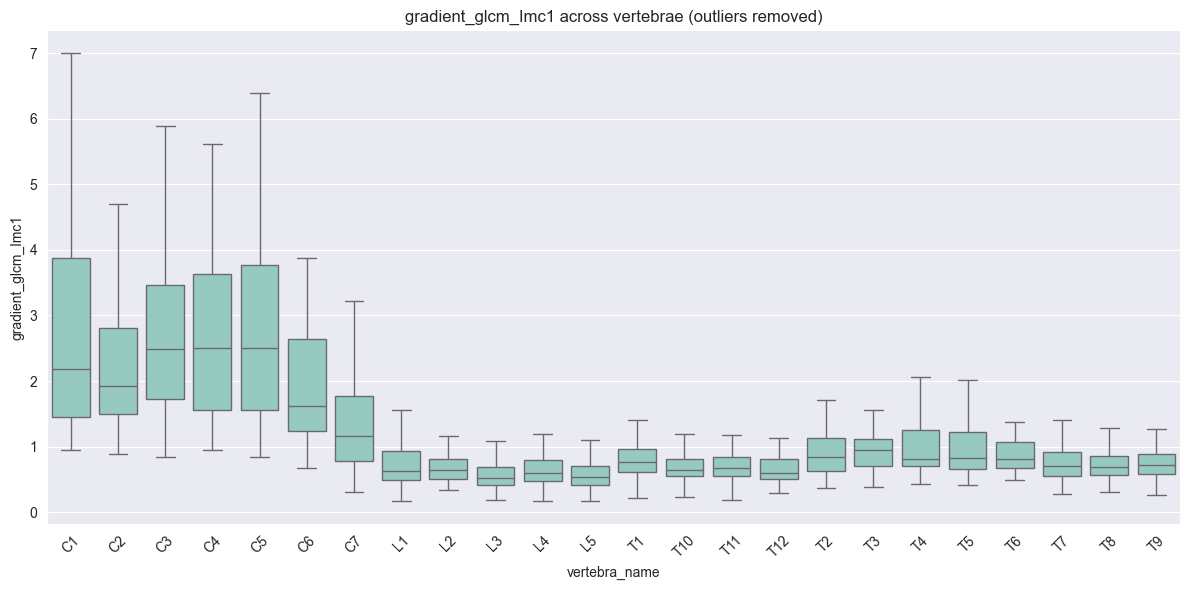

In [62]:
feature_name = 'gradient_glcm_Imc1'

plt.figure(figsize=(12,6))
sns.boxplot(x='vertebra_name', y=feature_name, data=df, showfliers=False, order=sorted(df['vertebra_name'].unique()))
plt.title(f'{feature_name} across vertebrae (outliers removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Difference in features between vertebra -> CaSupp25

In [63]:
import os
import pandas as pd
from scipy.stats import kruskal

main_folder = r"E:\DATA_Myelomy"
result_rows = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    l_path = os.path.join(folder_path, "CaSupp_25_radiomics_lesions_features.csv")
    v_path = os.path.join(folder_path, "CaSupp_25_radiomics_vertebrae_features.csv")

    if os.path.isfile(l_path) and os.path.isfile(v_path):
        df_l = pd.read_csv(l_path)
        df_v = pd.read_csv(v_path)

        df_l = df_l.set_index('vertebra_name')
        df_v = df_v.set_index('vertebra_name')

        common_cols = df_l.columns.intersection(df_v.columns)

        df_ratio = df_l[common_cols] / df_v[common_cols]

        df_ratio = df_ratio.reset_index()
        result_rows.append(df_ratio)

if not result_rows:
    print("Neboli nájdené žiadne dáta na spracovanie.")
else:
    df = pd.concat(result_rows, ignore_index=True)
    df = df[df['vertebra_name'] != 'S1'].dropna()

    results = []
    feature_cols = df.select_dtypes(include=['number']).columns

    for feature in feature_cols:
        groups = [group[feature].values for _, group in df.groupby('vertebra_name') if len(group) > 0]

        if len(groups) > 1:
            try:
                H, p = kruskal(*groups)
                results.append({'feature': feature, 'H_stat': H, 'p_value': p})
            except (ValueError, TypeError):
                continue

    results_df = pd.DataFrame(results).sort_values('H_stat', ascending=False)
results_df.head()

C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Analysis of multiple myelomas from dual CT\.venv\Lib\site-packages\scipy\stats\_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties


,feature,H_stat,p_value
139,gradient_glcm_Imc1,612.922191,8.956567e-115
48,original_glcm_InverseVariance,548.960719,2.189837e-101
190,gradient_gldm_LargeDependenceHighGrayLevelEmph...,545.446036,1.186961e-100
140,gradient_glcm_Imc2,540.085908,1.561388e-99
46,original_glcm_Imc1,438.665190,1.872074e-78


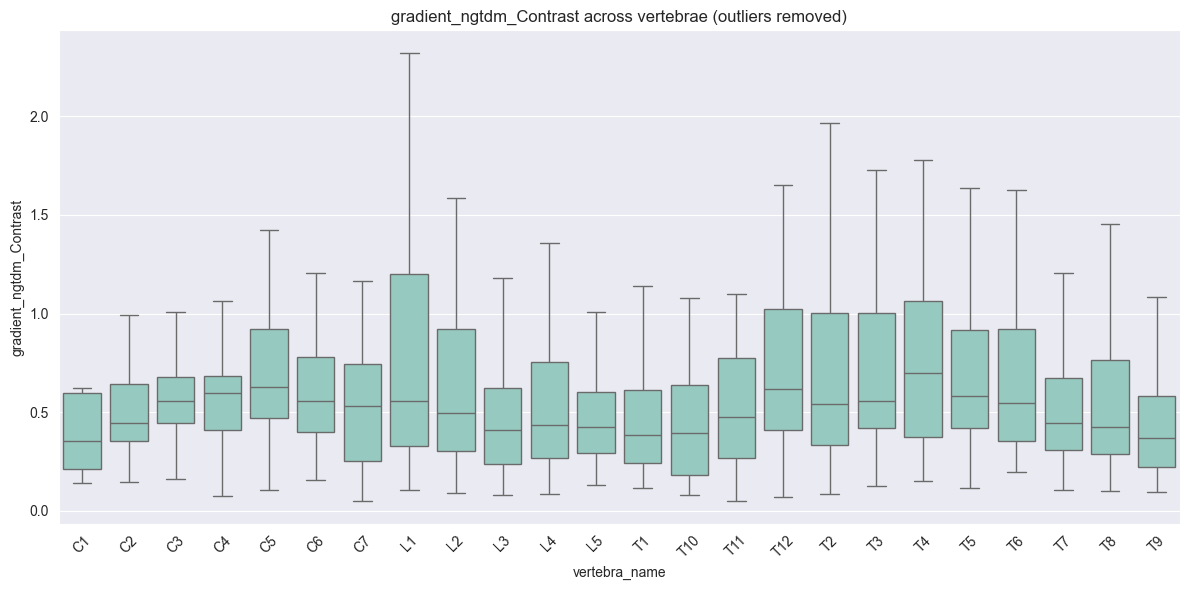

In [64]:
feature_name = 'gradient_ngtdm_Contrast'

plt.figure(figsize=(12,6))
sns.boxplot(x='vertebra_name', y=feature_name, data=df, showfliers=False, order=sorted(df['vertebra_name'].unique()))
plt.title(f'{feature_name} across vertebrae (outliers removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

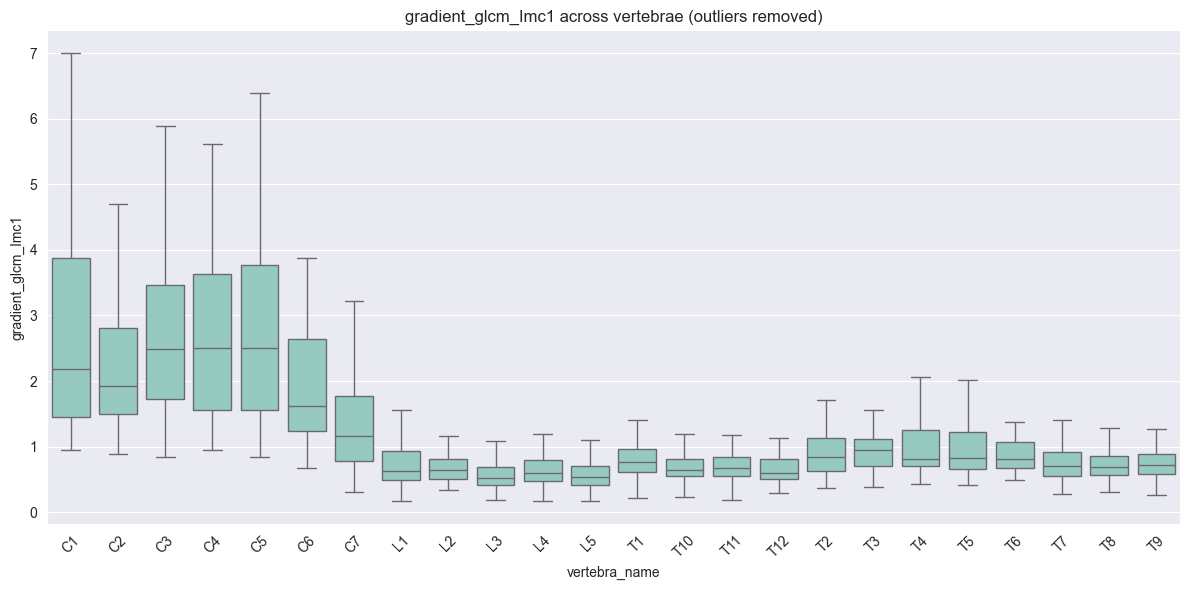

In [65]:
feature_name = 'gradient_glcm_Imc1'

plt.figure(figsize=(12,6))
sns.boxplot(x='vertebra_name', y=feature_name, data=df, showfliers=False, order=sorted(df['vertebra_name'].unique()))
plt.title(f'{feature_name} across vertebrae (outliers removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Pre štádia

# C/T/L analýza

C:\Users\Lukas\OneDrive - VUT\Plocha\Diploma thesis\Analysis of multiple myelomas from dual CT\.venv\Lib\site-packages\scipy\stats\_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties


                           feature      H_stat        p_value
139             gradient_glcm_Imc1  531.289755  4.284455e-116
48   original_glcm_InverseVariance  475.874753  4.624986e-104
140             gradient_glcm_Imc2  466.746247  4.439564e-102


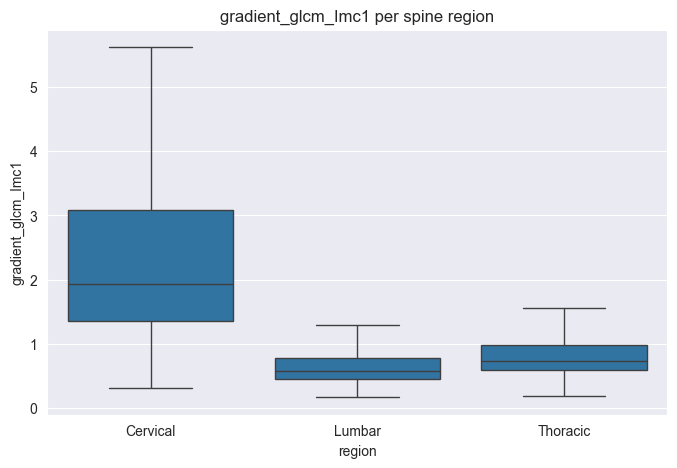

In [4]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# --- 1. Load all lesion CSVs ---
main_folder = r"E:\DATA_Myelomy"
result_rows = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    l_path = os.path.join(folder_path, "CaSupp_25_radiomics_lesions_features.csv")
    v_path = os.path.join(folder_path, "CaSupp_25_radiomics_vertebrae_features.csv")

    if os.path.isfile(l_path) and os.path.isfile(v_path):
        df_l = pd.read_csv(l_path)
        df_v = pd.read_csv(v_path)

        df_l = df_l.set_index('vertebra_name')
        df_v = df_v.set_index('vertebra_name')

        common_cols = df_l.columns.intersection(df_v.columns)

        df_ratio = df_l[common_cols] / df_v[common_cols]

        df_ratio = df_ratio.reset_index()
        result_rows.append(df_ratio)

if not result_rows:
    print("Neboli nájdené žiadne dáta na spracovanie.")
else:
    df = pd.concat(result_rows, ignore_index=True)
    df = df[df['vertebra_name'] != 'S1'].dropna()

    # --- 2. Define vertebra regions (C/T/L) ---
    cervical = [f'C{i}' for i in range(1,8)]
    thoracic = [f'T{i}' for i in range(1,13)]
    lumbar = [f'L{i}' for i in range(1,6)]

    def map_region(vertebra):
        if vertebra in cervical:
            return 'Cervical'
        elif vertebra in thoracic:
            return 'Thoracic'
        else:
            return 'Lumbar'

    df['region'] = df['vertebra_name'].apply(map_region)

    # --- 3. Identify numeric features automatically ---
    non_feature_cols = ['vertebra_name', 'region', 'patient']
    feature_cols = [c for c in df.columns if c not in non_feature_cols and pd.api.types.is_numeric_dtype(df[c])]

    # --- 6. Kruskal–Wallis test per feature ---
    kw_results = []
    for f in feature_cols:
        groups = [df.loc[df['region']==r, f].dropna().values for r in ['Cervical','Thoracic','Lumbar']]
        H, p = kruskal(*groups)
        n = df[f].notna().sum()
        kw_results.append({'feature': f, 'H_stat': H, 'p_value': p})

    kw_df = pd.DataFrame(kw_results).sort_values('H_stat', ascending=False)
    print(kw_df.head(3))

    # --- 7. Boxplot example for top feature ---
    top_feature = kw_df.iloc[0]['feature']
    plt.figure(figsize=(8,5))
    sns.boxplot(x='region', y=top_feature, data=df, showfliers=False)
    plt.title(f'{top_feature} per spine region')
    plt.ylabel(top_feature)
    plt.show()

Pre štádia

# tumor max burden by individual vertebra new features

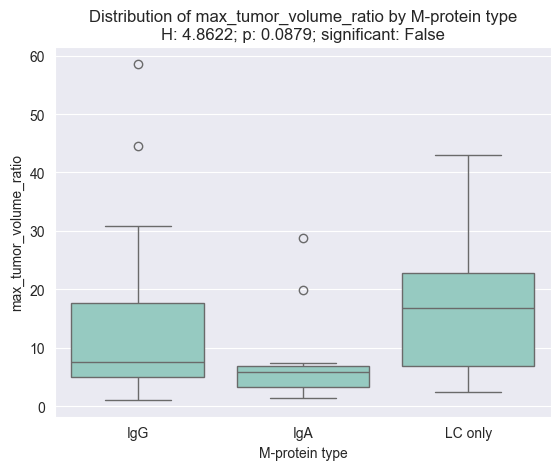

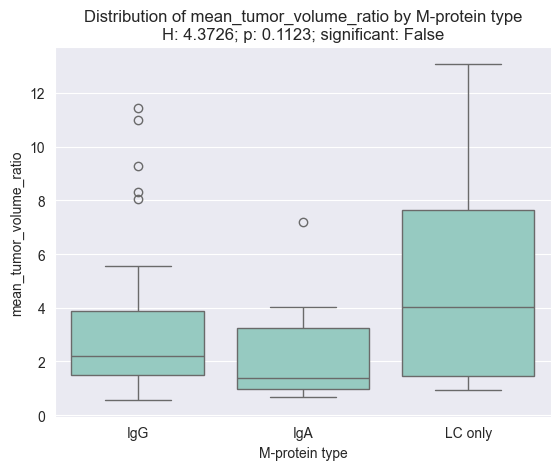

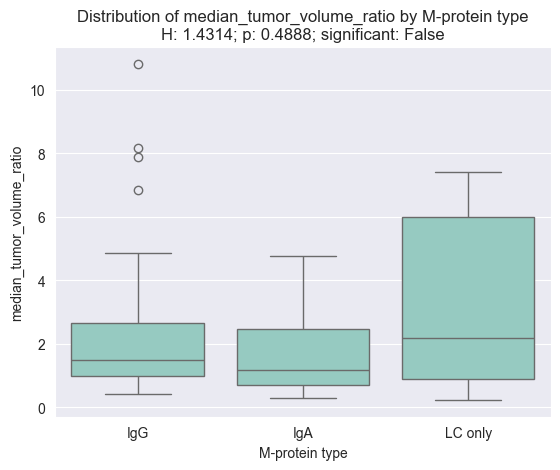

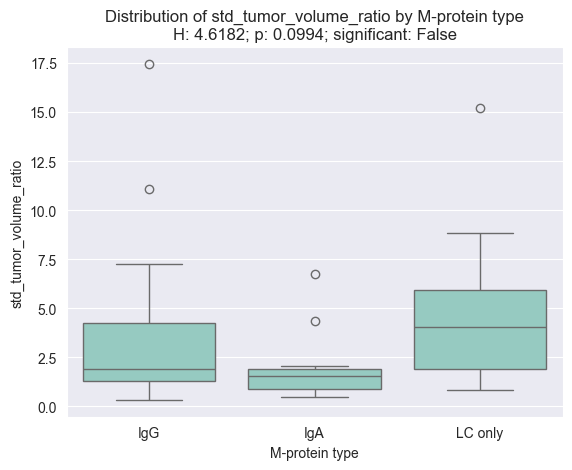

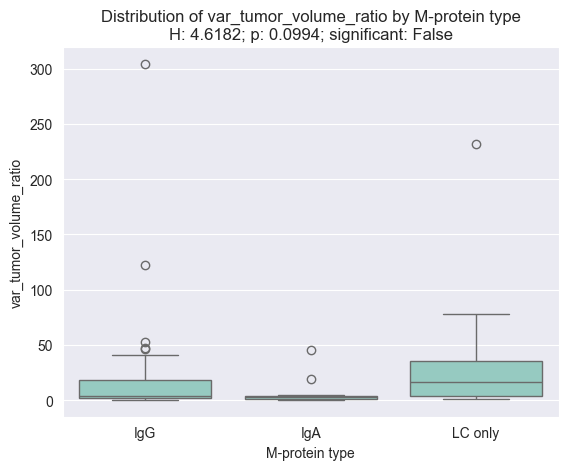

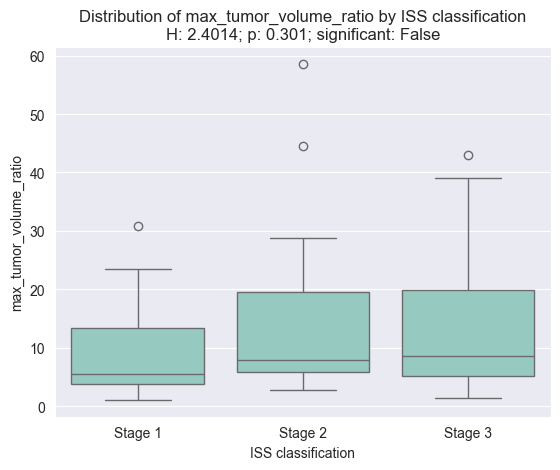

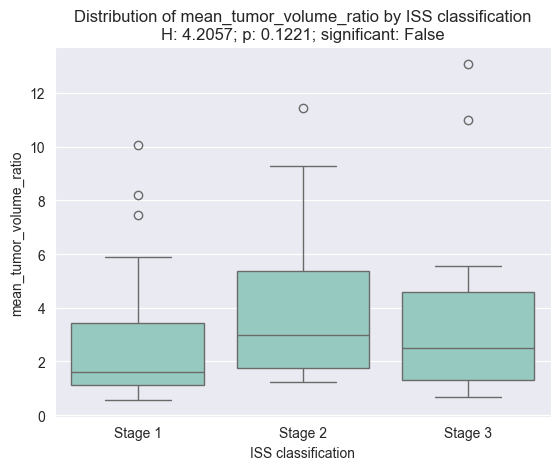

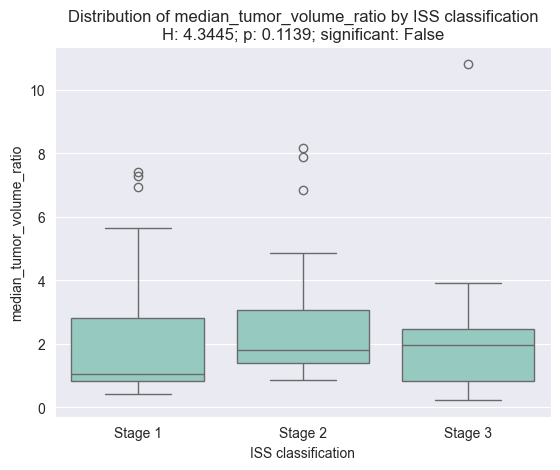

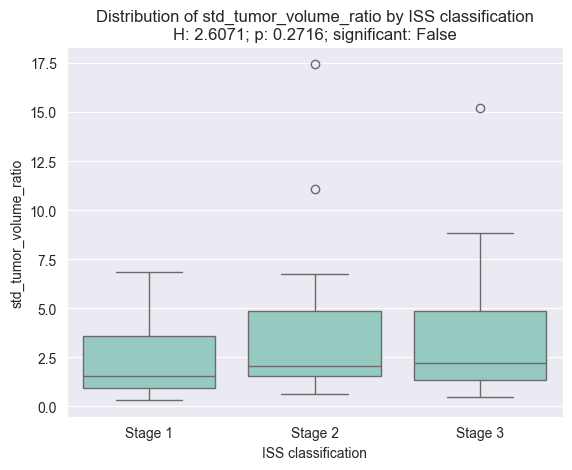

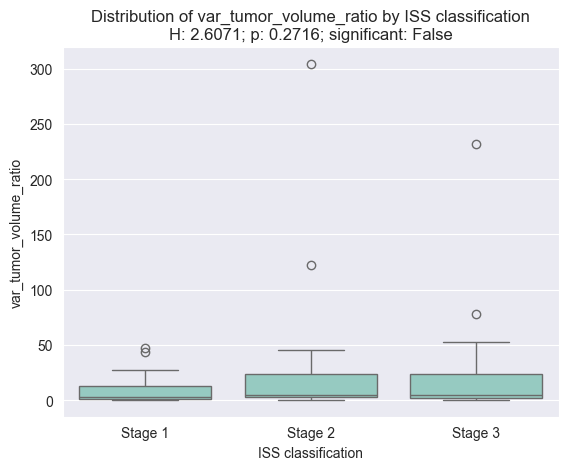

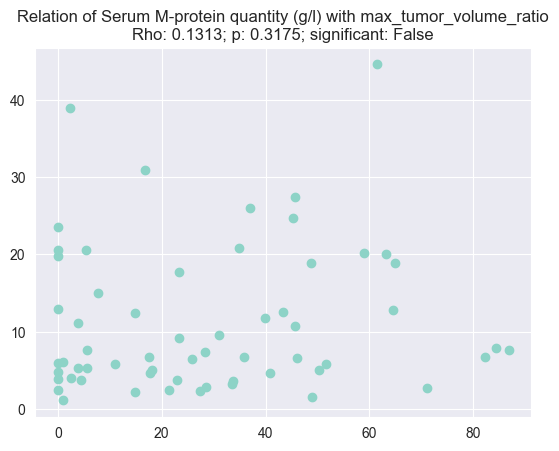

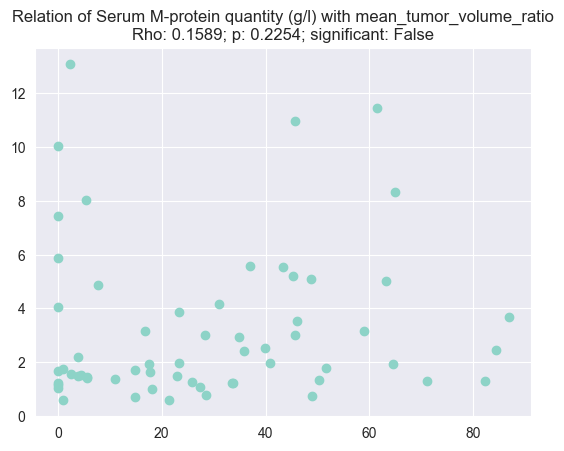

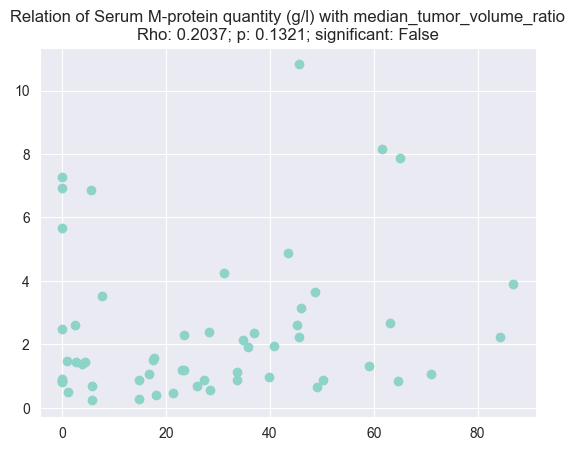

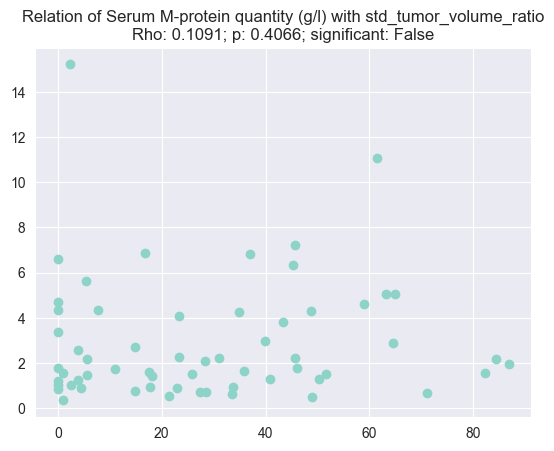

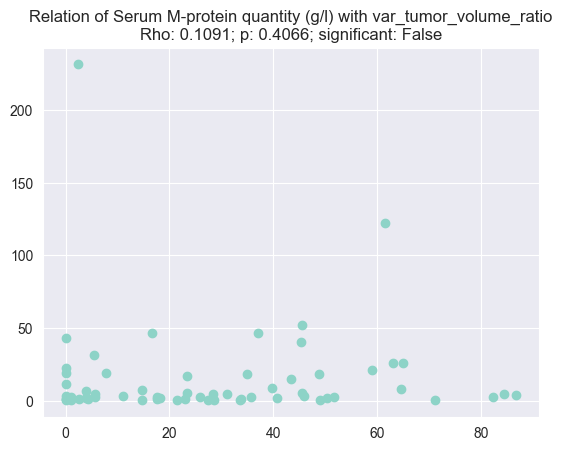

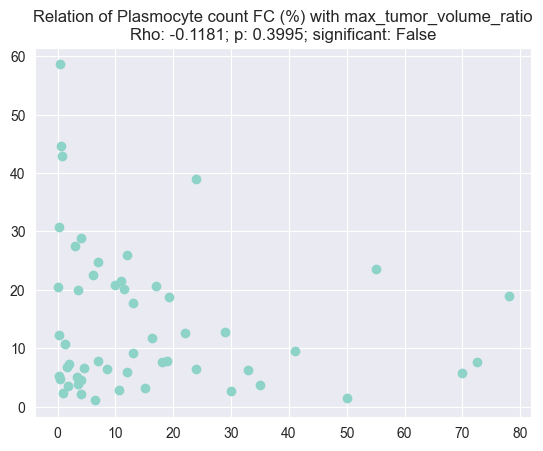

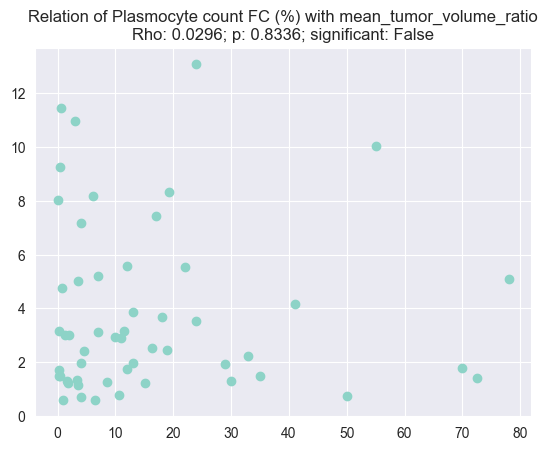

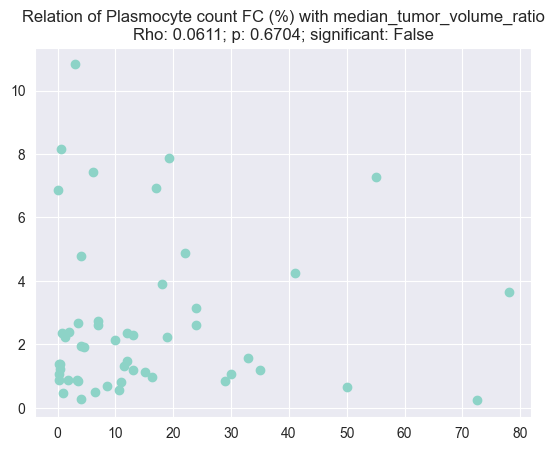

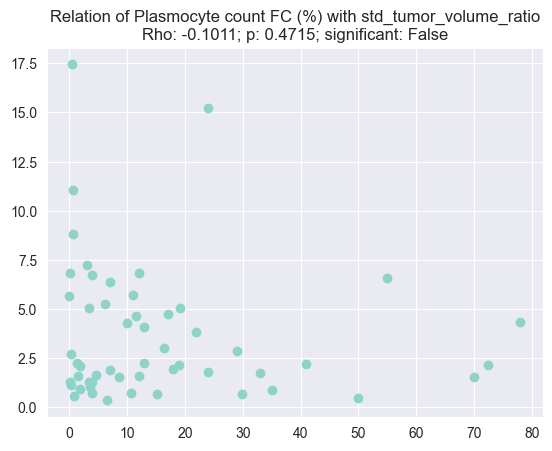

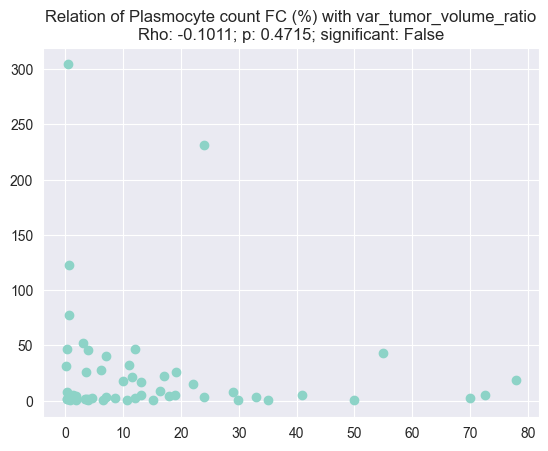

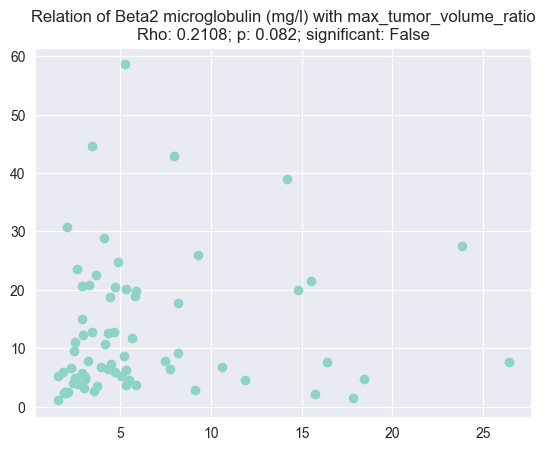

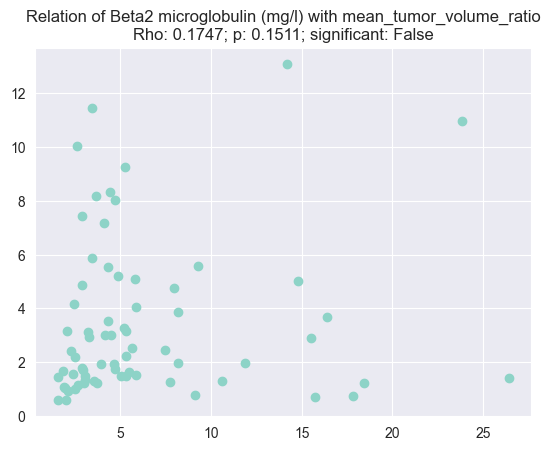

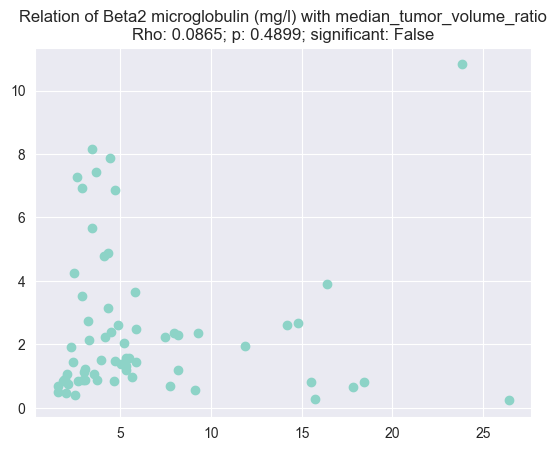

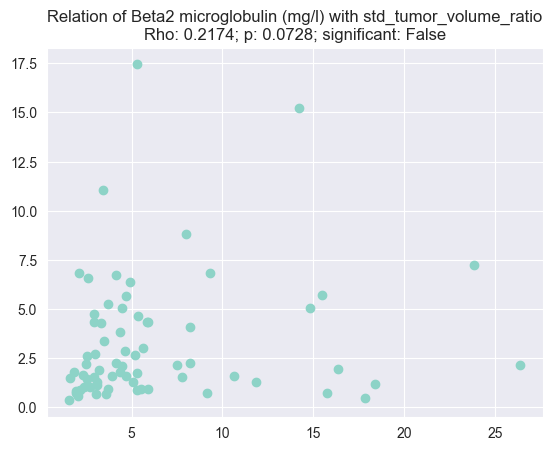

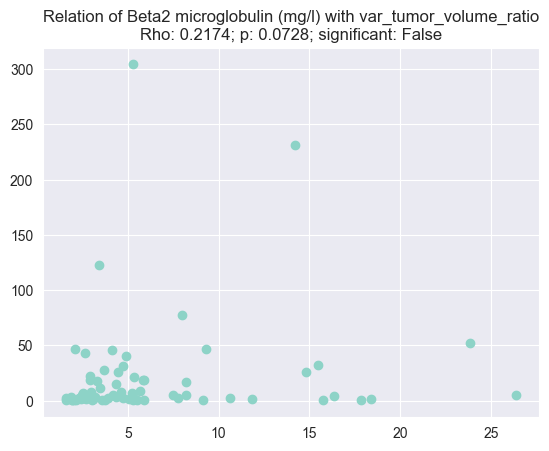

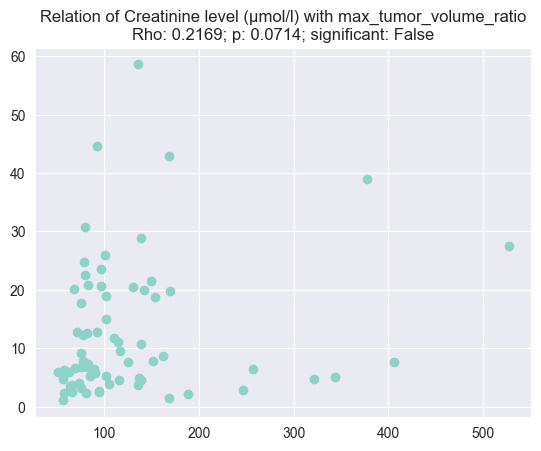

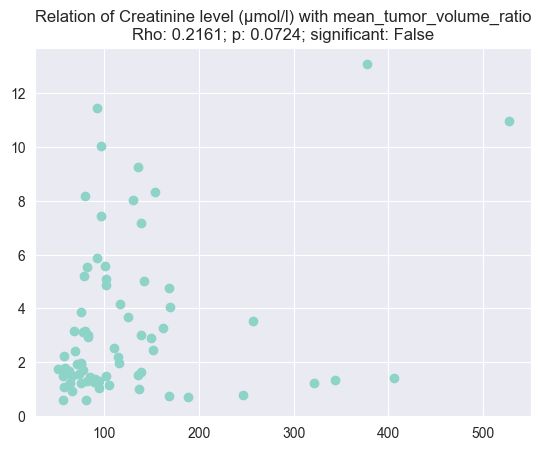

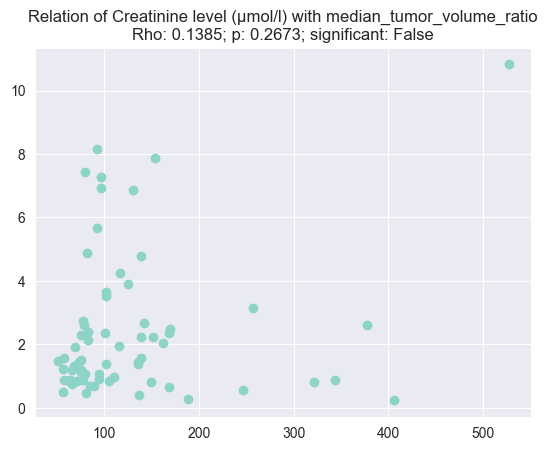

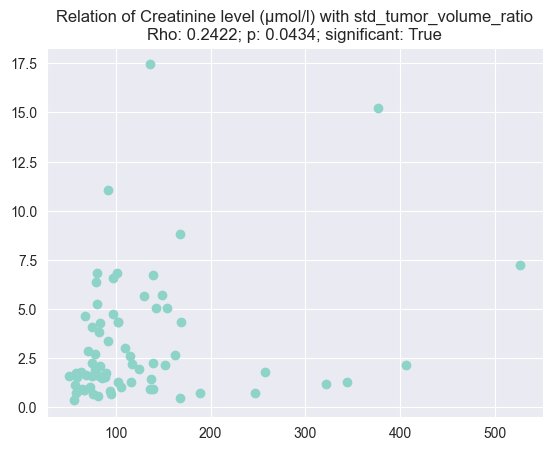

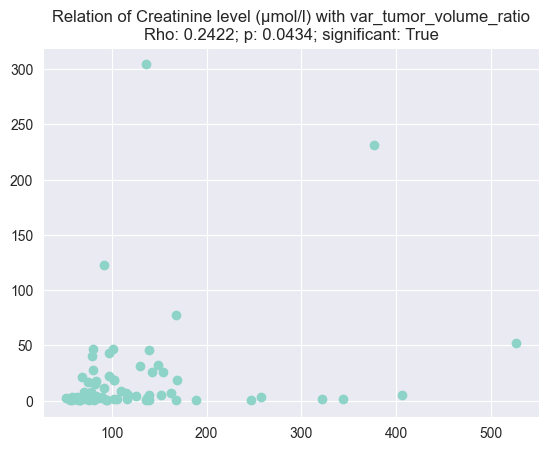

In [68]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr


main_folder = r"E:\DATA_Myelomy"
features = ["vertebra_name", "original_shape_VoxelVolume"]

result = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    lesions_path = os.path.join(folder_path, "BMD_radiomics_lesions_features.csv")
    vertebra_path = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")

    df_lesions = pd.read_csv(lesions_path).filter(items=features)
    df_vertebra = pd.read_csv(vertebra_path).filter(items=features)

    df_lesions["lesions_volume"] = df_lesions["original_shape_VoxelVolume"]
    df_vertebra["vertebra_volume"] = df_vertebra["original_shape_VoxelVolume"]

    merged_df = pd.merge(df_lesions, df_vertebra[['vertebra_name', 'vertebra_volume']],
                         left_on='vertebra_name', right_on='vertebra_name').drop("original_shape_VoxelVolume", axis=1)

    merged_df["tumor_volume_ratio"] = merged_df["lesions_volume"] / merged_df["vertebra_volume"] * 100

    temp = {
        "patient": folder_name,
        "max_tumor_volume_ratio": max(merged_df["tumor_volume_ratio"]),
        "mean_tumor_volume_ratio": np.mean(merged_df["tumor_volume_ratio"]),
        "median_tumor_volume_ratio": np.median(merged_df["tumor_volume_ratio"]),
        "std_tumor_volume_ratio": np.std(merged_df["tumor_volume_ratio"]),
        "var_tumor_volume_ratio": np.var(merged_df["tumor_volume_ratio"]),
    }

    result.append(temp)

data = pd.DataFrame(result)

pd.set_option('future.no_silent_downcasting', True)
categorical = ["M-protein type", "ISS classification"]
numeric = ["Serum M-protein quantity (g/l)", "Plasmocyte count FC (%)", "Beta2 microglobulin (mg/l)", "Creatinine level (µmol/l)"]
clinical_features = ["Patient ID"] + categorical + numeric
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[clinical_features], left_on='patient', right_on='Patient ID')

ratio_metrics = [col for col in df_final.columns if "tumor_volume_ratio" in col]


for category in categorical:
    for metric in ratio_metrics:
        groups = [group[metric].dropna().values for name, group in df_final.groupby(category)]

        if len(groups) > 1:
            stat, p = kruskal(*groups)

            sns.set_style("darkgrid")
            sns.boxplot(data=df_final, x=category, y=metric)
            plt.title(f'Distribution of {metric} by {category}\nH: {round(stat, 4)}; p: {round(p, 4)}; significant: {p < 0.05}')
            plt.show()

for num in numeric:
    for metric in ratio_metrics:
        subset = df_final[[num, metric]].dropna()

        if len(subset) > 1:
            rho, p = spearmanr(subset[num], subset[metric])

        plt.scatter(df_final[num], df_final[metric], label=metric)
        plt.title(f'Relation of {num} with {metric}\nRho: {round(rho, 4)}; p: {round(p, 4)}; significant: {p < 0.05}')
        plt.show()

prerozdeliť na regiony